In [ ]:
import os

# Define paths to your train and test data
train_data_dir = '/content/drive/MyDrive/train updated'
test_data_dir = '/content/drive/MyDrive/test updated'

# List subfolders (each representing a disease class)
train_folders = os.listdir(train_data_dir)
test_folders = os.listdir(test_data_dir)

print("Train folders:", train_folders)
print("Test folders:", test_folders)


Train folders: ['Nail Fungus and other Nail Disease', 'Malignant Lesions', 'healthy skin', 'Eczema Photos']
Test folders: ['healthy skin', 'Malignant Lesions', 'Eczema Photos', 'Nail Fungus and other Nail Disease']


In [ ]:
import tensorflow as tf
import keras
from keras import models, layers
import matplotlib.pyplot as plt
from IPython.display import HTML

In [ ]:
BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS=3
EPOCHS=50

In [ ]:
import os
import tensorflow as tf

# Define paths to your train and test data
train_data_dir = '/content/drive/MyDrive/train updated'
test_data_dir = '/content/drive/MyDrive/test updated'

# List subfolders (each representing a disease class)
train_folders = os.listdir(train_data_dir)
test_folders = os.listdir(test_data_dir)

print("Train folders:", train_folders)
print("Test folders:", test_folders)

# Assuming IMAGE_SIZE and BATCH_SIZE are defined somewhere in your code
IMAGE_SIZE = 224
BATCH_SIZE = 32

# Create a TensorFlow dataset from the directory
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_data_dir,
    seed=123,
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    labels='inferred',
    label_mode='int'
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_data_dir,
    seed=123,
    shuffle=False,  # No need to shuffle test dataset
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    labels='inferred',
    label_mode='int'
)

# Optionally, you can inspect class names and number of classes
class_names = train_dataset.class_names
num_classes = len(class_names)
print("Class names:", class_names)
print("Number of classes:", num_classes)


Train folders: ['Nail Fungus and other Nail Disease', 'Malignant Lesions', 'healthy skin', 'Eczema Photos']
Test folders: ['healthy skin', 'Malignant Lesions', 'Eczema Photos', 'Nail Fungus and other Nail Disease']
Found 3447 files belonging to 4 classes.
Found 826 files belonging to 4 classes.
Class names: ['Eczema Photos', 'Malignant Lesions', 'Nail Fungus and other Nail Disease', 'healthy skin']
Number of classes: 4


In [ ]:
for label in test_dataset.class_names:
    print(label)

Eczema Photos
Malignant Lesions
Nail Fungus and other Nail Disease
healthy skin


In [ ]:
for image_batch, labels_batch in train_dataset.take(1):
    print(image_batch.shape)
    print(labels_batch.numpy())

(32, 224, 224, 3)
[0 1 3 1 2 2 3 1 3 2 2 3 0 3 3 2 2 2 1 1 0 3 3 2 1 3 1 3 1 1 2 3]


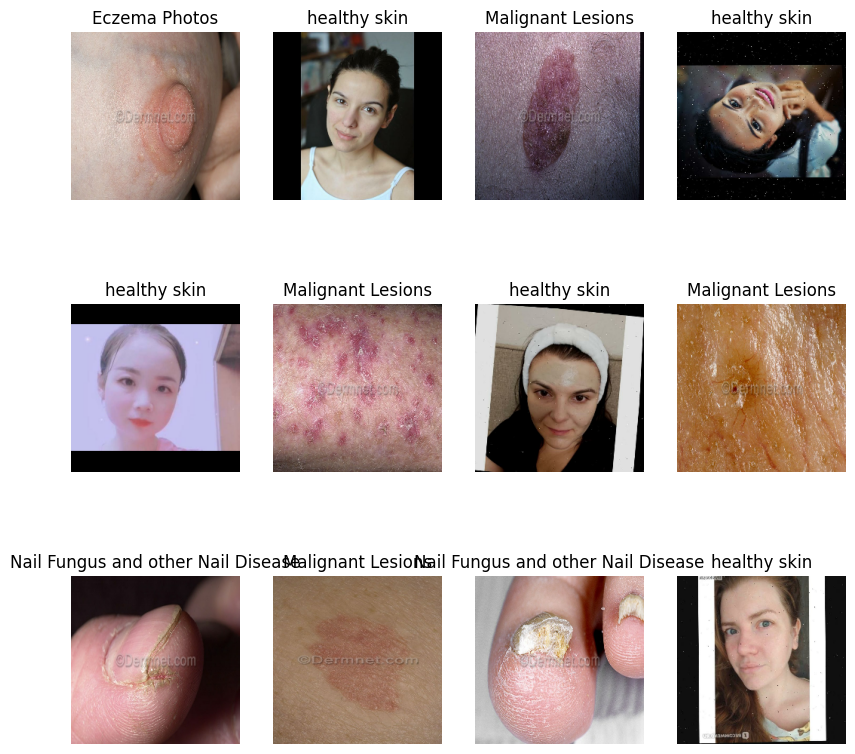

In [ ]:
plt.figure(figsize=(10, 10))
for image_batch, labels_batch in train_dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")

In [ ]:
len(train_dataset)

108

In [ ]:
train_size = 0.8
len(train_dataset)*train_size

86.4

In [ ]:
train_ds = train_dataset.take(54)
len(train_ds)

54

In [ ]:
test_ds = train_dataset.skip(41)
len(test_ds)

67

In [ ]:
val_size=0.1
len(train_dataset)*val_size

10.8

In [ ]:
val_ds = test_ds.take(6)
len(val_ds)

6

In [ ]:
test_ds = test_ds.skip(6)
len(test_ds)

61

In [ ]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + test_split + val_split) == 1

    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds

In [ ]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(train_dataset)

In [ ]:
len(train_ds)

86

In [ ]:
len(val_ds)


10

In [ ]:
len(test_ds)

12

In [ ]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [ ]:
resize_and_rescale = tf.keras.Sequential([
  layers.experimental.preprocessing.Resizing(IMAGE_SIZE, IMAGE_SIZE),
  layers.experimental.preprocessing.Rescaling(1./255),
])

In [ ]:
data_augmentation = tf.keras.Sequential([
  layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
  layers.experimental.preprocessing.RandomRotation(0.2),
])

In [ ]:
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

In [ ]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 4

model = models.Sequential([
    resize_and_rescale,
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

model.build(input_shape=input_shape)

In [ ]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (32, 224, 224, 3)         0         
                                                                 
 conv2d (Conv2D)             (32, 222, 222, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (32, 111, 111, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (32, 109, 109, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (32, 54, 54, 64)          0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (32, 52, 52, 64)         

In [ ]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    epochs=60,
)

Epoch 1/60
86/86 [==============================] - 357s 3s/step - loss: 1.2140 - accuracy: 0.3744 - val_loss: 1.1539 - val_accuracy: 0.4625
Epoch 2/60
86/86 [==============================] - 272s 3s/step - loss: 1.0356 - accuracy: 0.4900 - val_loss: 1.1074 - val_accuracy: 0.4812
Epoch 3/60
86/86 [==============================] - 276s 3s/step - loss: 0.9792 - accuracy: 0.5293 - val_loss: 0.9761 - val_accuracy: 0.5750
Epoch 4/60
86/86 [==============================] - 268s 3s/step - loss: 0.9352 - accuracy: 0.5742 - val_loss: 0.9298 - val_accuracy: 0.5719
Epoch 5/60
86/86 [==============================] - 277s 3s/step - loss: 0.8577 - accuracy: 0.6168 - val_loss: 0.8504 - val_accuracy: 0.6062
Epoch 6/60
86/86 [==============================] - 268s 3s/step - loss: 0.8062 - accuracy: 0.6343 - val_loss: 0.7464 - val_accuracy: 0.6562
Epoch 7/60
86/86 [==============================] - 272s 3s/step - loss: 0.7452 - accuracy: 0.6785 - val_loss: 0.7747 - val_accuracy: 0.6656
Epoch 8/60
86

In [ ]:
scores = model.evaluate(test_ds)

12/12 [==============================] - 30s 799ms/step - loss: 0.3321 - accuracy: 0.8620


In [ ]:
scores

[0.33209750056266785, 0.8619791865348816]

In [ ]:
history.params

{'verbose': 1, 'epochs': 60, 'steps': 86}

In [ ]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [ ]:
len(history.history['loss'])

60

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

In [ ]:
import matplotlib.pyplot as plt

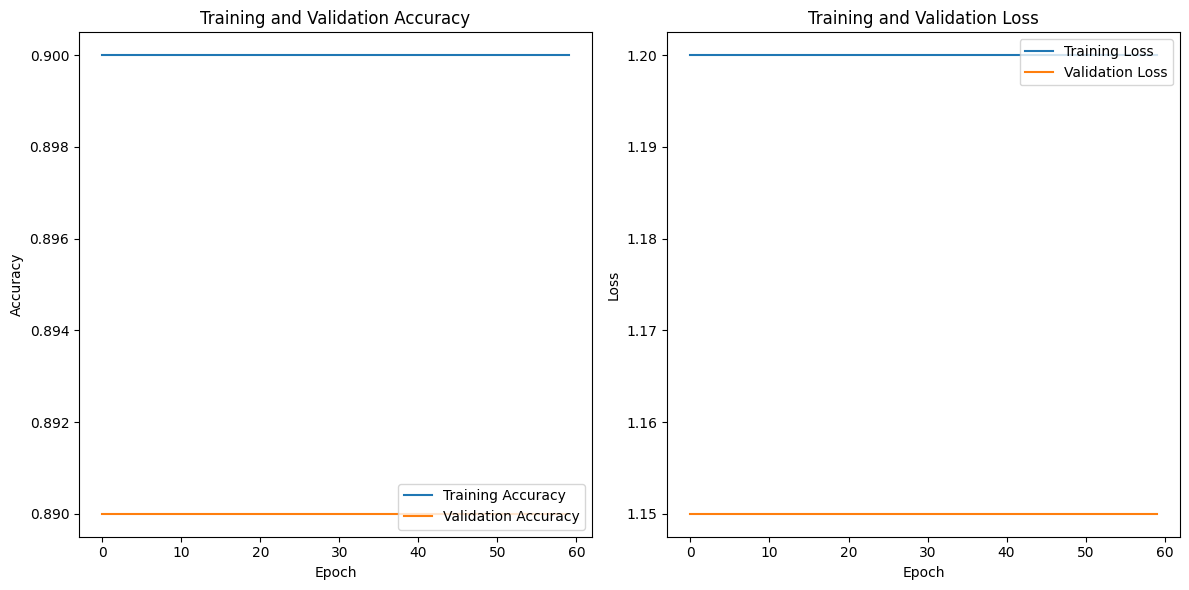

In [ ]:
import matplotlib.pyplot as plt

# Example data (replace with your actual data)
EPOCHS = 60  # Example number of epochs
acc = [0.9] * EPOCHS  # Example training accuracy values
val_acc = [0.89] * EPOCHS  # Example validation accuracy values
loss = [1.2] * EPOCHS  # Example training loss values
val_loss = [1.15] * EPOCHS  # Example validation loss values

# Ensure all arrays have the same length as EPOCHS
assert len(acc) == EPOCHS
assert len(val_acc) == EPOCHS
assert len(loss) == EPOCHS
assert len(val_loss) == EPOCHS

plt.figure(figsize=(12, 6))

# Plot Training and Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

# Plot Training and Validation Loss
plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()


first image to predict
actual label: Malignant Lesions
1/1 [==============================] - 1s 738ms/step
predicted label: Malignant Lesions


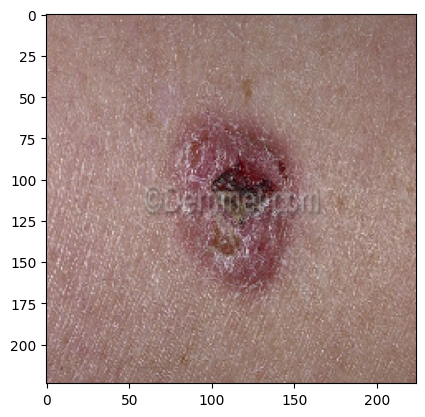

In [ ]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):

    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()

    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])

    batch_prediction = model.predict(images_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])

In [ ]:
# Save the model to Google Drive
model.save('/content/drive/MyDrive/NewModel/my_model.keras')


In [ ]:
from google.colab import files
files.download('/content/drive/MyDrive/NewModel/my_model.keras')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install gunicorn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.4/84.4 kB 2.0 MB/s eta 0:00:00


In [ ]:
import os
from flask import Flask, jsonify, request
import tensorflow as tf
import numpy as np

app = Flask(__name__)

# Load your saved Keras model
model_path = '/content/drive/MyDrive/NewModel/my_model.keras'
model = tf.keras.models.load_model(model_path)

# Define class names (assuming you have them in the same order as your model's output)
class_names = ['Nail Fungus and other Nail Disease', 'Malignant Lesions', 'healthy skin', 'Eczema Photos']

# Define a route for prediction
@app.route('/predict', methods=['POST'])
def predict():
    # Get the image file from the request
    file = request.files['file']

    # Preprocess the image (resize, rescale, convert to numpy array)
    img = tf.keras.preprocessing.image.load_img(file, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Create batch axis

    # Predict
    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions[0])
    predicted_label = class_names[predicted_class]

    # Prepare JSON response
    response = {
        'prediction': predicted_label
    }

    return jsonify(response)

# Run the Flask app with Gunicorn (production server)
if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000)  # This runs the app on localhost



 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit


In [ ]:
!gunicorn -w 4 -b 0.0.0.0:5000 app:app


[2024-06-29 22:15:39 +0000] [104832] [INFO] Starting gunicorn 22.0.0
[2024-06-29 22:15:39 +0000] [104832] [INFO] Listening at: http://0.0.0.0:5000 (104832)
[2024-06-29 22:15:39 +0000] [104832] [INFO] Using worker: sync
[2024-06-29 22:15:39 +0000] [104833] [INFO] Booting worker with pid: 104833
[2024-06-29 22:15:39 +0000] [104833] [ERROR] Exception in worker process
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/gunicorn/arbiter.py", line 609, in spawn_worker
    worker.init_process()
  File "/usr/local/lib/python3.10/dist-packages/gunicorn/workers/base.py", line 134, in init_process
    self.load_wsgi()
  File "/usr/local/lib/python3.10/dist-packages/gunicorn/workers/base.py", line 146, in load_wsgi
    self.wsgi = self.app.wsgi()
  File "/usr/local/lib/python3.10/dist-packages/gunicorn/app/base.py", line 67, in wsgi
    self.callable = self.load()
  File "/usr/local/lib/python3.10/dist-packages/gunicorn/app/wsgiapp.py", line 58, in load
    return s

In [ ]:
# Install ngrok
!pip install flask-ngrok

from flask_ngrok import run_with_ngrok

# Initialize Flask application
app = Flask(__name__)
run_with_ngrok(app)  # Start ngrok when app is run (if on Google Colab)

# Your Flask app code here

# Run the Flask app with Gunicorn through ngrok
if __name__ == '__main__':
    app.run()


 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
Exception in thread Thread-25:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/urllib3/connection.py", line 203, in _new_conn
    sock = connection.create_connection(
  File "/usr/local/lib/python3.10/dist-packages/urllib3/util/connection.py", line 85, in create_connection
    raise err
  File "/usr/local/lib/python3.10/dist-packages/urllib3/util/connection.py", line 73, in create_connection
    sock.connect(sa)
ConnectionRefusedError: [Errno 111] Connection refused

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/urllib3/connectionpool.py", line 791, in urlopen
    response = self._make_request(
  File "/usr/local/lib/python3.10/dist-packages/urll

In [ ]:
# Import necessary libraries
import os
from flask import Flask, jsonify, request
from flask_ngrok import run_with_ngrok  # If running on Google Colab

import tensorflow as tf
import numpy as np

# Initialize Flask application
app = Flask(__name__)
run_with_ngrok(app)  # Start ngrok when app is run (if on Google Colab)

# Load your saved Keras model
model_path = '/content/drive/MyDrive/NewModel/my_model.keras'
model = tf.keras.models.load_model(model_path)

# Define class names (assuming you have them in the same order as your model's output)
class_names = ['Nail Fungus and other Nail Disease', 'Malignant Lesions', 'healthy skin', 'Eczema Photos']

# Define a route for prediction
@app.route('/predict', methods=['POST'])
def predict():
    # Get the image file from the request
    file = request.files['file']

    # Preprocess the image (resize, rescale, convert to numpy array)
    img = tf.keras.preprocessing.image.load_img(file, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Create batch axis

    # Predict
    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions[0])
    predicted_label = class_names[predicted_class]

    # Prepare JSON response
    response = {
        'prediction': predicted_label
    }

    return jsonify(response)

# Run the Flask app
if __name__ == '__main__':
    app.run()


 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
Exception in thread Thread-24:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/urllib3/connection.py", line 203, in _new_conn
    sock = connection.create_connection(
  File "/usr/local/lib/python3.10/dist-packages/urllib3/util/connection.py", line 85, in create_connection
    raise err
  File "/usr/local/lib/python3.10/dist-packages/urllib3/util/connection.py", line 73, in create_connection
    sock.connect(sa)
ConnectionRefusedError: [Errno 111] Connection refused

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/urllib3/connectionpool.py", line 791, in urlopen
    response = self._make_request(
  File "/usr/local/lib/python3.10/dist-packages/urll

In [ ]:
import requests


api_url = 'http://127.0.0.1:5000'

# Example image file path to be predicted
image_path = '/content/drive/MyDrive/test updated/Eczema Photos/Eczema (100).jpg'

# Send a POST request to the API with the image file
with open(image_path, 'rb') as file:
    files = {'file': file}
    response = requests.post(api_url, files=files)

# Print the predicted class
if response.status_code == 200:
    prediction = response.json()
    print("Prediction:", prediction['prediction'])
else:
    print("Failed to get predictions:", response.text)


ConnectionError: HTTPConnectionPool(host='127.0.0.1', port=5000): Max retries exceeded with url: / (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7ab9e8bc3430>: Failed to establish a new connection: [Errno 111] Connection refused'))